### This notebook uses the custom scarlet implementation in DeepDISC to create segmentation masks and bounding boxes for DP1 cutouts 


It assumes the image cutouts are saved in .npy files (one for each band, containing the array for every image in that band).  Each image cutout is centered on one object in the training/test set.  

We also need the photo-z training and test catalogs `dp1_matched_v4_train`/`dp1_matched_v4_test`, found on NERSC.  These contain RA,DEC, spec-zs and  photometric information.  

Finally, we take the catalog of objects found within each cutout `train_v4_cutout_catalog_{i}.csv` and the wcs of each cutout stored in `test_wcs_dict.json`.  These are also created on NERSC

In [ ]:
# Standard imports
import sys, os
import numpy as np
import time
import glob

import scarlet
import sep

import astropy.io.fits as fits
from astropy.wcs import WCS
from astropy.stats import gaussian_fwhm_to_sigma
from astropy.coordinates import SkyCoord

from scarlet.display import AsinhMapping
from astropy.nddata import Cutout2D

# DeepDISC imports
import deepdisc.preprocessing.detection as detection
import deepdisc.preprocessing.process as process

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import matplotlib
import matplotlib.pyplot as plt

# use a better colormap and don't interpolate the pixels
#matplotlib.rc('image', cmap='gray', interpolation='none', origin='lower')
from skimage.util.shape import view_as_blocks
from matplotlib import colors

import pandas as pd
import h5py
import json
from astropy.visualization import make_lupton_rgb

from deepdisc.data_format.file_io import DDLoader
from deepdisc.data_format.annotation_functions.annotate_dp1 import annotate_dp1
from deepdisc.data_format import conversions
from deepdisc.data_format.conversions import fitsim_to_numpy
from deepdisc.data_format.file_io import convert_to_json, get_data_from_json

In [2]:
with h5py.File('/home/g4merz/DP1/dp1_matched_v4_test.hdf5','r') as f:
    redshifts = f['redshift'][:]
    ras = f['coord_ra'][:]
    decs = f['coord_dec'][:]
    objectIds = f['objectId'][:]
    
len(ras)

2905

In [3]:
image_u = np.load('train_v4_cutouts_u.npy')
image_g = np.load('train_v4_cutouts_g.npy')
image_r = np.load('train_v4_cutouts_r.npy')
image_i = np.load('train_v4_cutouts_i.npy')
image_z = np.load('train_v4_cutouts_z.npy')
image_y = np.load('train_v4_cutouts_y.npy')

outdir = '/home/g4merz/DP1/processed_data/'


In [67]:
i = 10
test_image = np.array((image_u[i],image_g[i],image_r[i],image_i[i],image_z[i],image_y[i]))
img = make_lupton_rgb(test_image[3],test_image[2],test_image[1],stretch=15,Q=10)

In [68]:
catalog = pd.read_csv(f'/home/g4merz/DP1/catalogs/train_v4_cutout_catalog_{i}.csv')

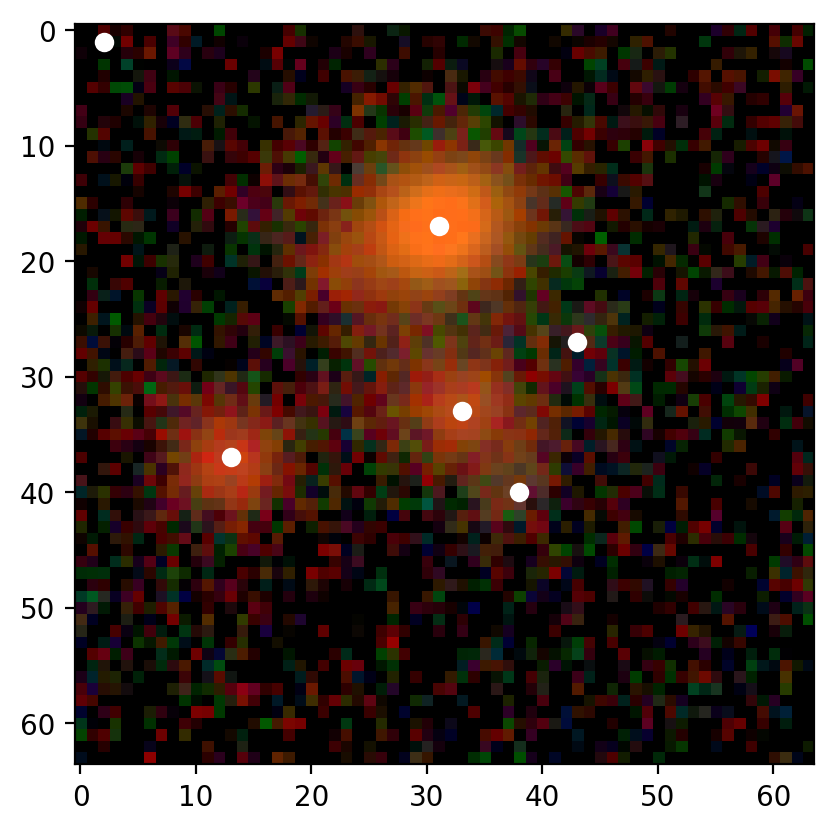

In [69]:
plt.imshow(img)
plt.scatter(catalog.x.values,catalog.y.values,c='w')

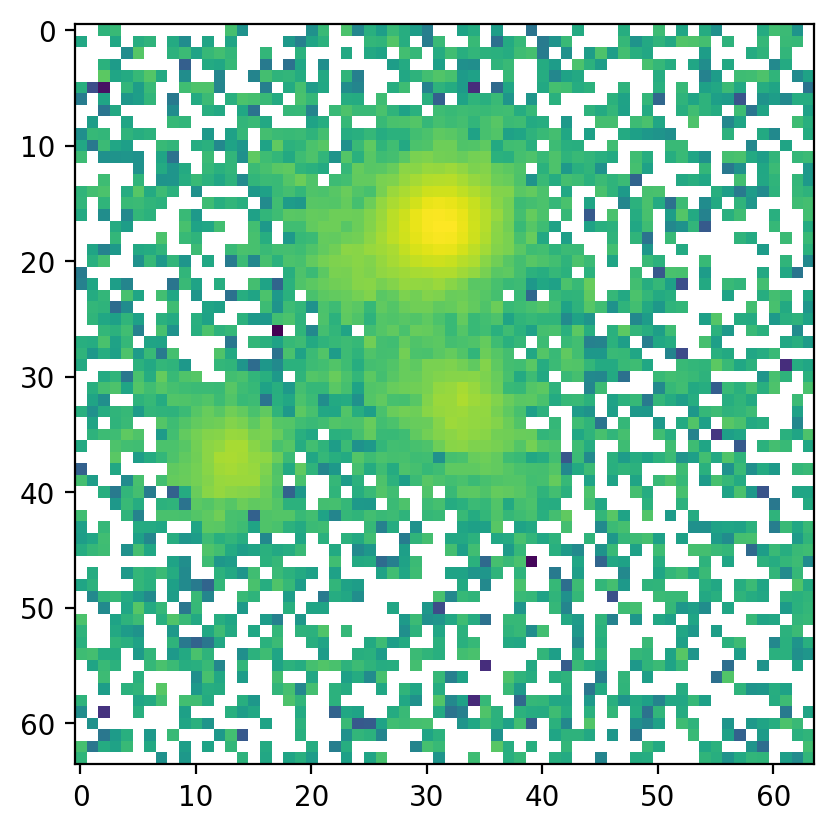

In [70]:
plt.imshow(image_z[i],norm=colors.LogNorm())

In [9]:

#This function is specific to the data format. You will need your own function to load custom data

def generate_training_data_example(sp, outdir='/home/g4merz/DP1/processed_data/', plot_image=False, plot_stretch_Q=False, plot_scene=False,
                                   plot_likelihood=False, write_results=True, filters = ['u','g','r','i','z','y']):
    """
    Parameters
    ----------
    c : SkyCoord object
          The ra, dec pointing (single or lists of pointings)
    plot_image : bool
          Whether or not to plot the image
    plot_stretch_Q : bool
          Whether or not to plot different normalizations of your image using the stretch, Q parameters.
    plot_scene : bool
           Whether or not plot scene with scarlet
    plot_likelihood : bool
           Whether or not plot the log likelihood of the scarlet fitting
    write_results : bool
          Whether or not to write results to FITS file
    cutout_size : [int, int]
          Cutout shape of image
          
    Returns
    -------
    The scarlet image test in FITS files.
    
    """

        
    ### Run scarlet on image ###
    #datas = test_image = np.array((image_u[sp],image_g[sp],image_r[sp],image_i[sp],image_z[sp],image_y[sp]))
    #catalog = pd.read_csv(f'/home/g4merz/DP1/catalogs/train_v4_cutout_catalog_{sp}.csv')

    datas = np.load(f'/home/g4merz/DP1/processed_data/test_v4_cutouts_{sp}.npy')
    catalog = pd.read_csv(f'/home/g4merz/DP1/catalogs/test_v4_cutout_catalog_{sp}.csv')
    
    # Image pixel scale in arcsec/pixel
    ps = 0.2
    # Approximate PSF size, you can use a PSF image instead
    sigma_obs = gaussian_fwhm_to_sigma*0.8/ps
       
    # Run Scarlet
    out = detection.run_scarlet(datas, filters, catalog=catalog, lvl=2, sigma_model=1, sigma_obs=sigma_obs, psf=None, plot_scene=plot_scene,
                         max_chi2=1000000, morph_thresh=1, stretch=15, Q=10, 
                         plot_wavelet=False, plot_likelihood=plot_likelihood, plot_sources=False, add_ellipses=True,
                         add_labels=False, add_boxes=False, lvl_segmask=0.5, maskthresh=0.005,return_models=False, percentiles=(30,90))

    # Unpack output
    observation, starlet_sources, model_frame, catalog, segmentation_masks = out

    
    # Save Scarlet data to FITS file
    if write_results:
        filenames = process.write_scarlet_results_nomodels(datas, observation, starlet_sources, model_frame, 
                                             segmentation_masks, outdir=outdir, 
                                             filters=filters, s=f'{sp}', catalog=catalog, keys=['objectId'])
    
        print(f'\nSaved scarlet results as {filenames} \n')
    
    #return out
        

Failed to initialize source 0
Failed to initialize source 1
Failed to initialize source 2
Failed to initialize source 3
Failed to initialize source 4
Failed to initialize source 5


Source catalog has  6 objects
[(11, 43), (56, 13), (33, 33), (53, 61), (33, 5), (25, 23)]
Initializing starlet sources to be fit.
Fitting Blend model.
Scarlet ran for 15 iterations to logL = -53416723.52641231
0.4862709045410156
Extracting deblended catalog.


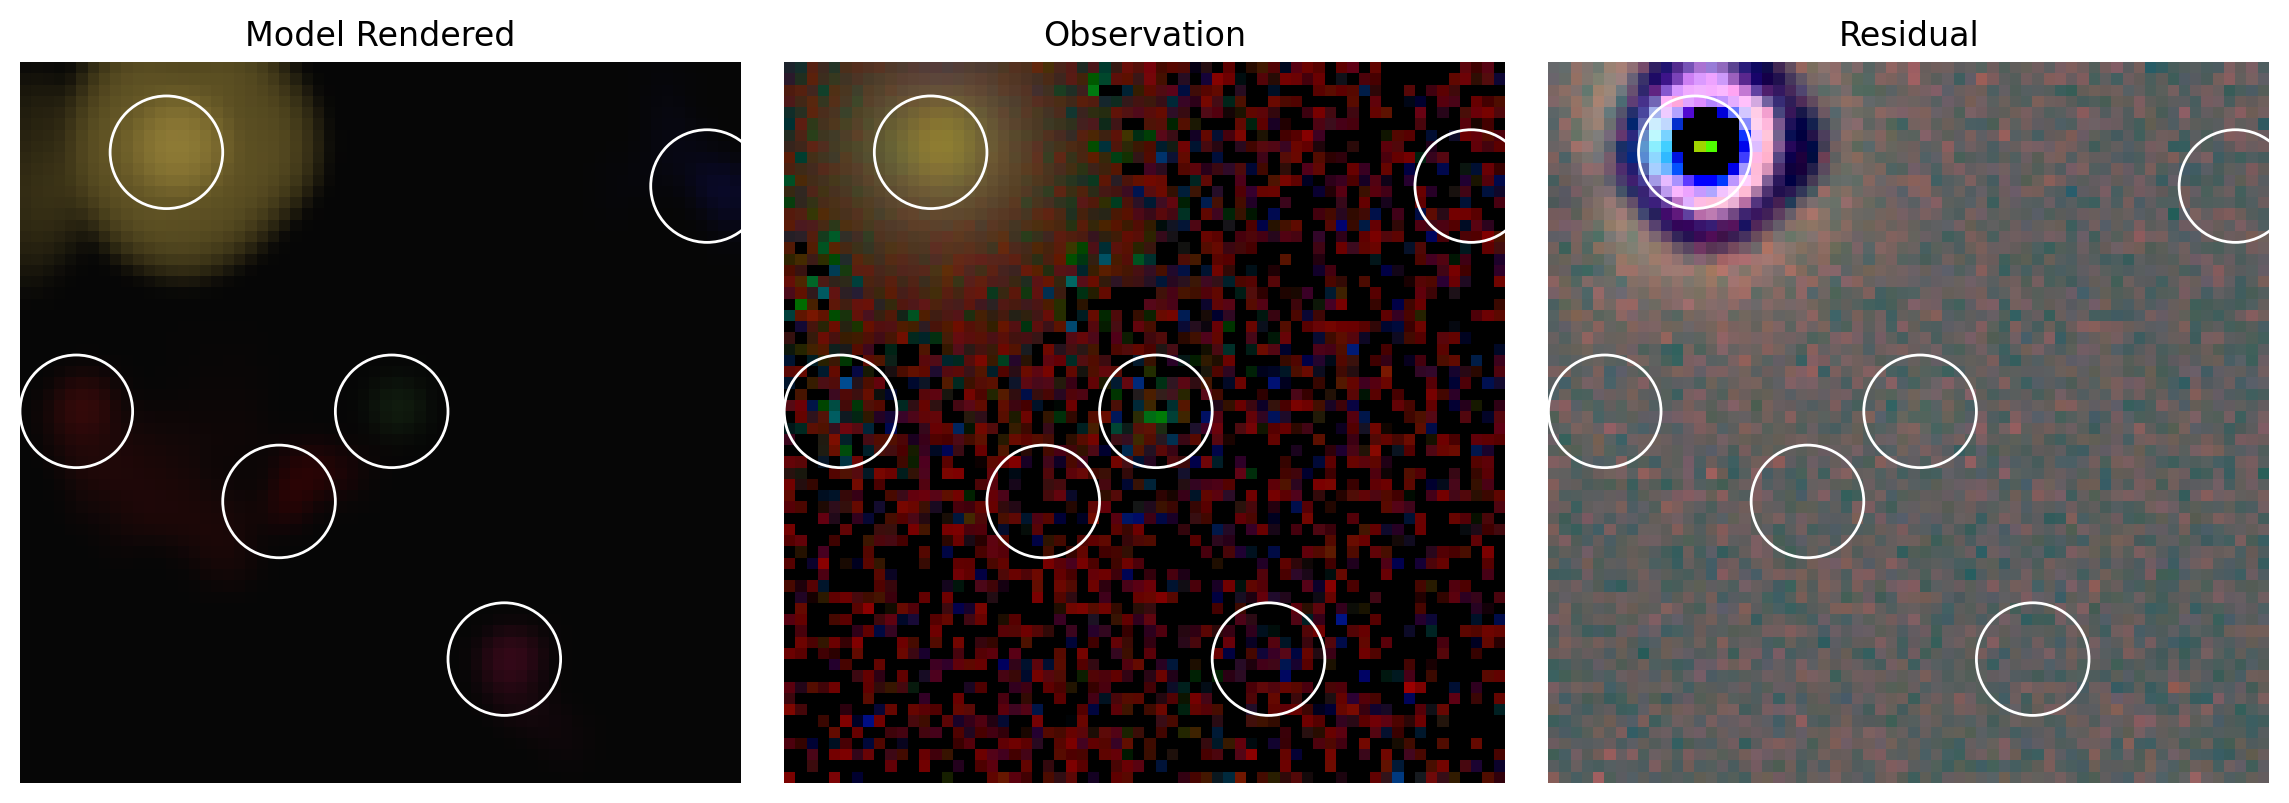


Saved scarlet results as {'img_u': '/home/g4merz/DP1/processed_data/test/u_img_340.fits', 'img_g': '/home/g4merz/DP1/processed_data/test/g_img_340.fits', 'img_r': '/home/g4merz/DP1/processed_data/test/r_img_340.fits', 'img_i': '/home/g4merz/DP1/processed_data/test/i_img_340.fits', 'img_z': '/home/g4merz/DP1/processed_data/test/z_img_340.fits', 'img_y': '/home/g4merz/DP1/processed_data/test/y_img_340.fits', 'segmask': '/home/g4merz/DP1/processed_data/test/masks_340.fits'} 



In [11]:
#2164 [611255759837082632, 611255759837082641] 611255759837082657
#2174 [611256447031849731, 611256447031849894] 611256447031849896
i=340
out = generate_training_data_example(sp=i, outdir='/home/g4merz/DP1/processed_data/test/', plot_scene=True)

In [12]:
#outdir = '/home/g4merz/DP1/processed_data/'

loader = DDLoader().generate_filedict('/home/g4merz/DP1/processed_data/test/', ['u', 'g', 'r', 'i', 'z','y'], '*img*.fits', '*mask*',filt_loc=0)
filedict = loader.filedict
img_files = np.transpose([filedict[filt]["img"] for filt in filedict["filters"]])

In [13]:
from deepdisc.data_format import conversions
from deepdisc.data_format.conversions import fitsim_to_numpy
from deepdisc.data_format.file_io import convert_to_json, get_data_from_json
#dfile = os.path.join(outdir,'train_dicts.json')


In [15]:

#dataset_dicts2=[]
#dataset_dicts2 = loader.generate_dataset_dict(annotate_dp1,dirpath='/home/g4merz/DP1/processed_data/test/').get_dataset()  
#len(dataset_dicts2)

2

In [120]:

#convert_to_json(dataset_dicts2, '/home/g4merz/DP1/processed_data/test/test_dicts_replace.json')

Caching COCO format annotations at '/home/g4merz/DP1/processed_data/test/test_dicts_replace.json' ...


In [116]:
#dataset_dicts = get_data_from_json('/home/g4merz/DP1/processed_data/test/test_dicts.json')

In [118]:
from detectron2.data import MetadataCatalog, DatasetCatalog

if 'astro_test' in MetadataCatalog and 'astro_test' in DatasetCatalog:
    DatasetCatalog.remove("astro_test")
    MetadataCatalog.remove("astro_test")

from deepdisc.data_format.register_data import register_data_set
import matplotlib.pyplot as plt
from detectron2.utils.visualizer import Visualizer
from detectron2.utils.visualizer import ColorMode

from astropy.visualization import make_lupton_rgb

from matplotlib import colors
from deepdisc.astrodet.visualizer import ColorMode

red = np.array(colors.to_rgb('red'))*255
white = np.array(colors.to_rgb('white'))*255
blue = np.array(colors.to_rgb('blue'))*255
green = np.array(colors.to_rgb('green'))*255

DatasetCatalog.register("astro_test", lambda: get_metadata())
#astrotest_metadata = MetadataCatalog.get("astro_test").set(thing_classes=["star","galaxy","bad_fit","unknown"]).set(thing_colors=[red,green,white,blue])
#astrotest_metadata = MetadataCatalog.get("astro_test").set(thing_classes=["star","galaxy","bad_fit"]).set(thing_colors=[red,green,white])
#astrotest_metadata = MetadataCatalog.get("astro_test").set(thing_classes=["object"]).set(thing_colors=[white])
astrotest_metadata = MetadataCatalog.get("astro_test").set(thing_classes=["object"]).set(thing_colors=[green])
#astrotest_metadata = MetadataCatalog.get("astro_test")

total instances: 6


Text(0.5, 1.0, 'Ground Truth')

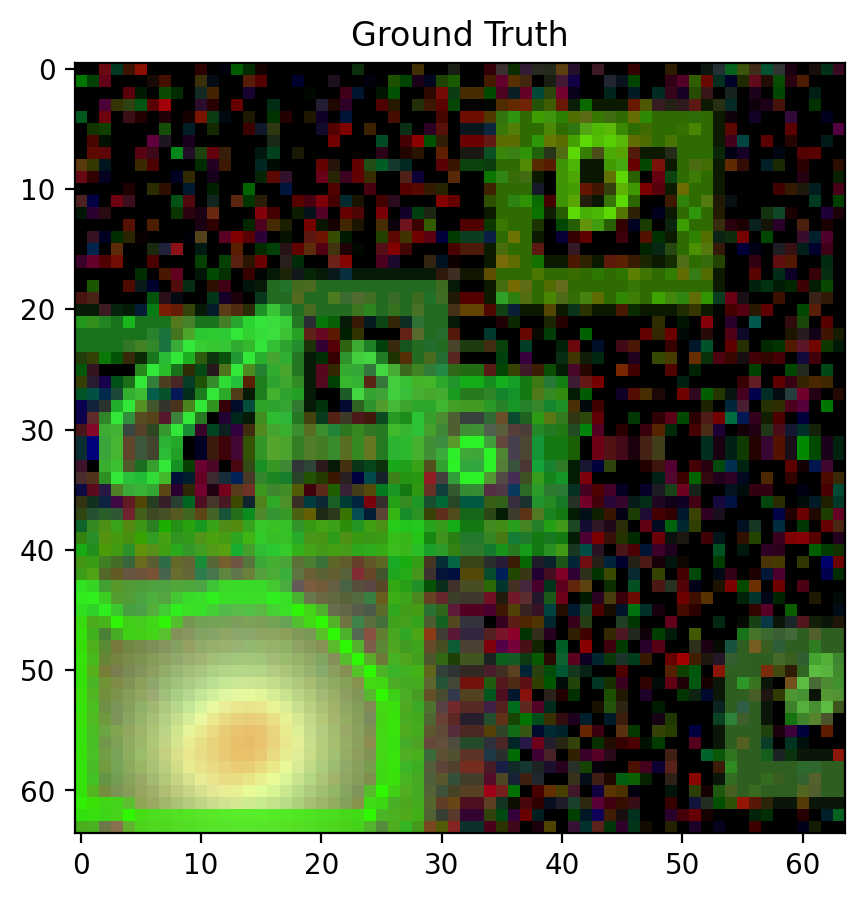

In [119]:
import matplotlib.pyplot as plt
from deepdisc.astrodet.visualizer import Visualizer
from deepdisc.astrodet.visualizer import ColorMode

from astropy.visualization import make_lupton_rgb

plt.figure(figsize=(5,5))

i = 340
#d = dataset_dicts[i]
d = dataset_dicts2[1]
imgind = int(d['filename'].split('/')[-1].split('.npy')[0][4:])

test_image = np.load(f'/home/g4merz/DP1/processed_data/test_v4_cutouts_{imgind}.npy')
img = make_lupton_rgb(test_image[3],test_image[2],test_image[1],stretch=15,Q=10)


print("total instances:", len(d["annotations"]))
v0 = Visualizer(
    img,
    metadata=astrotest_metadata,
    scale=1,
    instance_mode=ColorMode.SEGMENTATION,  # remove the colors of unsegmented pixels. This option is only available for segmentation models
)
groundTruth = v0.draw_dataset_dict(d, lf=False, alpha=0.1)

ax1 = plt.subplot(1, 1, 1)
ax1.imshow(groundTruth.get_image())
#ax1.axis("off")
plt.title('Ground Truth')

#plt.savefig('/home/g4merz/JWST/plots/ex_im_annos.png')

In [62]:
fitsim_to_numpy(img_files,outdir)

In [37]:
for file in glob.glob(os.path.join('/home/g4merz/DP1/processed_data/test/','*.fits')):
    os.remove(file)

In [ ]:
t0 = time.time()

inds = np.arange(len(image_u))
#inds = np.arange(24)


from functools import partial

import multiprocessing as mp
with mp.Pool(processes=30) as pool:
    results = pool.map(partial(generate_training_data_example,outdir='/home/g4merz/DP1/processed_data/'),inds)
    
print(time.time()-t0,' seconds')

In [6]:
#outdir = '/home/g4merz/DP1/processed_data/'
loader = DDLoader().generate_filedict('/home/g4merz/DP1/processed_data/', ['u', 'g', 'r', 'i', 'z','y'], '*img*.fits', '*mask*',filt_loc=0)
filedict = loader.filedict
img_files = np.transpose([filedict[filt]["img"] for filt in filedict["filters"]])

In [8]:
import ntpath
start_index = 2
stop_index=-2
print(img_files[1001][-1])
bn = os.path.basename(img_files[1001][-1]).split('.fits')[0]
os.path.join(os.path.dirname(img_files[1001][-1]), bn[start_index:])+'.npy'
#img_files[1001][-1].split('.fits')[0]#[start_index:stop_index]+'.npy'

/home/g4merz/DP1/processed_data/y_img_19.fits


'/home/g4merz/DP1/processed_data/img_19.npy'

In [9]:

dataset_dicts=[]
dataset_dicts = loader.generate_dataset_dict(annotate_dp1,dirpath=outdir).get_dataset()  


In [10]:
fitsim_to_numpy(img_files,outdir,start_index=2)

In [79]:
for file in glob.glob(os.path.join(outdir,'*.fits')):
    os.remove(file)

In [17]:
dfile = os.path.join(outdir,'train_dicts.json')
convert_to_json(dataset_dicts, dfile)

Caching COCO format annotations at '/home/g4merz/DP1/processed_data/train_dicts.json' ...


### Add redshift

In [5]:
testf = 'dp1_matched_v4_train.hdf5'

with h5py.File(testf,'r') as f:
    objectIds = f['objectId'][:]
    redshifts = f['redshift'][:]
    ras = f['coord_ra'][:]
    decs = f['coord_dec'][:]

In [7]:
dataset_dicts = get_data_from_json('/home/g4merz/DP1/processed_data/test/train_dicts.json')

In [17]:
#check to make sure the centered object exists in each cutout metadata
# Object 5976 was missing due to segmask rejection, lowered threshold and reran for that cutout
ddnew = []
for i in range(len(dataset_dicts)):
    if i==2164:
        ddnew.append(dataset_dicts2[0])
    elif i==2174:
        ddnew.append(dataset_dicts2[1])
    else:
        ddnew.append(dataset_dicts[i])
convert_to_json(ddnew, '/home/g4merz/DP1/processed_data/train_dicts_new.json')

Caching COCO format annotations at '/home/g4merz/DP1/processed_data/test_dicts_new.json' ...


In [20]:
for j,d in enumerate(dataset_dicts):
    imgind = int(d['filename'].split('/')[-1].split('.npy')[0][4:])
    #print(d['filename'],imgind)

    ids = [a['objectId'] for a in d['annotations']]
    
    oid = objectIds[imgind]
    
    if oid not in ids:
        print(j, imgind, ids, oid)

In [19]:
dataset_dicts = get_data_from_json('/home/g4merz/DP1/processed_data/train_dicts_new.json')

In [21]:
for j,d in enumerate(dataset_dicts):
    for a in d['annotations']:
        if a['objectId'] in objectIds:
            cati = np.where(objectIds==a['objectId'])[0][0]
            a['redshift'] = redshifts[cati]
        else:
            a['redshift'] = -1
convert_to_json(dataset_dicts, '/home/g4merz/DP1/processed_data/train_dicts_new.json')

Caching COCO format annotations at '/home/g4merz/DP1/processed_data/test_dicts_new.json' ...


### Add WCS

In [98]:
from astropy.wcs import WCS 

# WCS list from NERSC will be ordered by the order of the training set objects. 
# I.e., first dict corresponds to first object in training set.  This number will be in the filename of the dataset dicts

wcs_dict  = get_data_from_json('/home/g4merz/DP1/test_wcs_dict.json')

In [99]:
dataset_dicts = get_data_from_json('/home/g4merz/DP1/processed_data/test_dicts_new.json')

In [100]:
for j,d in enumerate(dataset_dicts):
    imgind = int(d['filename'].split('/')[-1].split('.npy')[0][4:])
    d['wcs'] = wcs_dict[imgind]

In [101]:
convert_to_json(dataset_dicts, '/home/g4merz/DP1/processed_data/train_dicts_new.json')

Caching COCO format annotations at '/home/g4merz/DP1/processed_data/test_dicts_new.json' ...
